# Cross-Modal Retrieval [Step 3 - Text-to-Image and Image-to-Text Search]

> **MLCourse - Agentic AI - Multi-Modal RAG**

## What you will learn

1. How to query a multi-modal ChromaDB index with text AND image queries.
2. Text-to-image retrieval: find images that match a text description.
3. Image-to-text retrieval: find text chunks relevant to an image.
4. How ranking works when searching across modalities.
5. Combining text and image results into a unified ranking.

This notebook builds on notebook 02's index. If you have not run that
notebook yet, the cells at the top rebuild the index from scratch so
this file is self-contained.

In [1]:
# ---------------------------------------------------------------------------
# Setup cell (identical in every MLCourse notebook): imports, TRACK walker,
# DATA folder creation, .env loading, matplotlib inline magic - guarded so
# the file also runs as a plain script outside Jupyter.
# ---------------------------------------------------------------------------
from pathlib import Path


def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until a directory named ``target`` shows up."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(
        f"Could not find '{target}' above {start}. "
        "Open this notebook from inside the MLCourse repository."
    )


TRACK = find_track(Path.cwd())       # .../MLCourse/03_agentic_ai
DATA = TRACK / "data"                # one shared data folder for the track
DATA.mkdir(exist_ok=True)            # no-op when it already exists

from dotenv import load_dotenv       # noqa: E402  reads KEY=value files

load_dotenv()                        # .env beside the current directory
load_dotenv(TRACK / ".env")          # .env at the track root

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass                             # silently skip the magic outside IPython

import matplotlib.pyplot as plt      # noqa: E402

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


In [2]:
# ## Part 1: Load Dependencies and CLIP Model

import subprocess, sys

def install_if_missing(package: str, import_name: str = None):
    name = import_name or package
    try:
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

install_if_missing("pymupdf", "fitz")
install_if_missing("open-clip-torch", "open_clip")
install_if_missing("chromadb")
install_if_missing("Pillow")

import torch
import open_clip
from PIL import Image
import chromadb
import numpy as np
import fitz
import io

device = "cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu"
)

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
tokenizer = open_clip.get_tokenizer("ViT-B-32")
model = model.to(device).eval()

print(f"[CLIP] Loaded ViT-B-32 on {device}")

[CLIP] Loaded ViT-B-32 on cpu


In [3]:
# ## Part 2: Build the Index (or Load Existing)
#
# This cell rebuilds the multi-modal index if the ChromaDB directory
# does not exist yet. If it does exist, we skip to loading.

CHROMA_DIR = TRACK / "data" / "chroma_multimodal"
client = chromadb.PersistentClient(path=str(CHROMA_DIR))

def build_index():
    """Extract images and text from the PDF and index them."""
    print("[INDEX] Building index from scratch...")
    PDF_PATH = DATA / "attention_is_all_you_need.pdf"
    EXTRACT_DIR = DATA / "multimodal_images"
    EXTRACT_DIR.mkdir(exist_ok=True)

    doc = fitz.open(str(PDF_PATH))

    # -- Extract images --
    extracted_images = []
    for page_num in range(len(doc)):
        page = doc[page_num]
        for img_idx, img_info in enumerate(page.get_images(full=True)):
            xref = img_info[0]
            base_image = doc.extract_image(xref)
            img_bytes = base_image["image"]
            ext = base_image["ext"]
            img_name = f"page{page_num + 1}_img{img_idx + 1}.{ext}"
            img_path = EXTRACT_DIR / img_name
            with open(img_path, "wb") as f:
                f.write(img_bytes)
            img = Image.open(io.BytesIO(img_bytes))
            w, h = img.size
            if w < 50 or h < 50:
                img_path.unlink()
                continue
            extracted_images.append({
                "path": str(img_path), "name": img_name,
                "page": page_num + 1, "width": w, "height": h,
            })

    # -- Extract text --
    text_chunks = []
    for page_num in range(len(doc)):
        page = doc[page_num]
        text = page.get_text("text")
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
        for para_idx, para in enumerate(paragraphs):
            if len(para) < 20:
                continue
            text_chunks.append({
                "text": para, "page": page_num + 1,
                "chunk_id": f"page{page_num + 1}_para{para_idx}",
                "source": PDF_PATH.name,
            })
    doc.close()

    # -- Embed texts --
    all_text = [c["text"] for c in text_chunks]
    text_vecs = []
    for i in range(0, len(all_text), 32):
        batch = all_text[i:i + 32]
        tokens = tokenizer(batch).to(device)
        with torch.no_grad():
            vecs = model.encode_text(tokens)
            vecs = vecs / vecs.norm(dim=-1, keepdim=True)
        text_vecs.append(vecs.cpu())
    text_embeddings = torch.cat(text_vecs, dim=0)

    # -- Embed images --
    img_tensors = [preprocess(Image.open(p).convert("RGB")).unsqueeze(0)
                   for p in [e["path"] for e in extracted_images]]
    img_vecs = []
    for i in range(0, len(img_tensors), 8):
        batch = torch.cat(img_tensors[i:i + 8], dim=0).to(device)
        with torch.no_grad():
            vecs = model.encode_image(batch)
            vecs = vecs / vecs.norm(dim=-1, keepdim=True)
        img_vecs.append(vecs.cpu())
    image_embeddings = torch.cat(img_vecs, dim=0) if img_vecs else torch.zeros(0, 512)

    # -- Create ChromaDB collections --
    try:
        client.delete_collection("multimodal_text")
        client.delete_collection("multimodal_images")
    except Exception:
        pass

    tc = client.create_collection("multimodal_text", metadata={"hnsw:space": "cosine"})
    ic = client.create_collection("multimodal_images", metadata={"hnsw:space": "cosine"})

    tc.add(
        ids=[c["chunk_id"] for c in text_chunks],
        embeddings=text_embeddings.numpy().tolist(),
        documents=all_text,
        metadatas=[{"page": c["page"], "source": c["source"], "type": "text"}
                    for c in text_chunks],
    )
    if extracted_images:
        ic.add(
            ids=[e["name"] for e in extracted_images],
            embeddings=image_embeddings.numpy().tolist(),
            documents=[e["name"] for e in extracted_images],
            metadatas=[{"page": e["page"], "path": e["path"],
                         "width": e["width"], "height": e["height"], "type": "image"}
                        for e in extracted_images],
        )
    print(f"[INDEX] Built: {tc.count()} text, {ic.count()} images")
    return tc, ic

# Try to get existing collections; build if empty.
try:
    text_col = client.get_collection("multimodal_text")
    img_col = client.get_collection("multimodal_images")
    if text_col.count() == 0:
        text_col, img_col = build_index()
    else:
        print(f"[INDEX] Loaded existing: {text_col.count()} text, {img_col.count()} images")
except Exception:
    text_col, img_col = build_index()

[INDEX] Loaded existing: 15 text, 3 images


In [4]:
# ## Part 3: Text-to-Image Retrieval
#
# Given a text query, search the image collection for matching visuals.
# This is the "I know what I want, show me the diagram" use case.

def text_to_image_query(query: str, top_k: int = 3) -> list[dict]:
    """Search the image collection with a text query."""
    tokens = tokenizer([query]).to(device)
    with torch.no_grad():
        qvec = model.encode_text(tokens)
        qvec = qvec / qvec.norm(dim=-1, keepdim=True)

    results = img_col.query(
        query_embeddings=qvec.numpy().tolist(),
        n_results=min(top_k, img_col.count()),
    )
    hits = []
    for i in range(len(results["ids"][0])):
        hits.append({
            "id": results["ids"][0][i],
            "document": results["documents"][0][i],
            "distance": results["distances"][0][i],
            "metadata": results["metadatas"][0][i],
        })
    return hits

# Demo queries.
TEXT_QUERIES = [
    "attention mechanism architecture",
    "transformer model performance comparison",
    "encoder decoder structure",
]

for q in TEXT_QUERIES:
    hits = text_to_image_query(q, top_k=3)
    print(f"\nText query: \"{q}\"")
    print("-" * 60)
    for rank, h in enumerate(hits, 1):
        # distance in ChromaDB cosine = 1 - cosine_similarity
        sim = 1 - h["distance"]
        bar = "#" * int(sim * 40)
        print(f"  #{rank} sim={sim:.4f}  page {h['metadata']['page']:<3}  "
              f"{h['document']:<30} {bar}")


Text query: "attention mechanism architecture"
------------------------------------------------------------
  #1 sim=0.2745  page 4    page4_img2.png                 ##########
  #2 sim=0.2668  page 4    page4_img1.png                 ##########
  #3 sim=0.2532  page 3    page3_img1.png                 ##########

Text query: "transformer model performance comparison"
------------------------------------------------------------
  #1 sim=0.2192  page 4    page4_img1.png                 ########
  #2 sim=0.2138  page 3    page3_img1.png                 ########
  #3 sim=0.2012  page 4    page4_img2.png                 ########

Text query: "encoder decoder structure"
------------------------------------------------------------
  #1 sim=0.2751  page 4    page4_img2.png                 ###########
  #2 sim=0.2692  page 3    page3_img1.png                 ##########
  #3 sim=0.2352  page 4    page4_img1.png                 #########


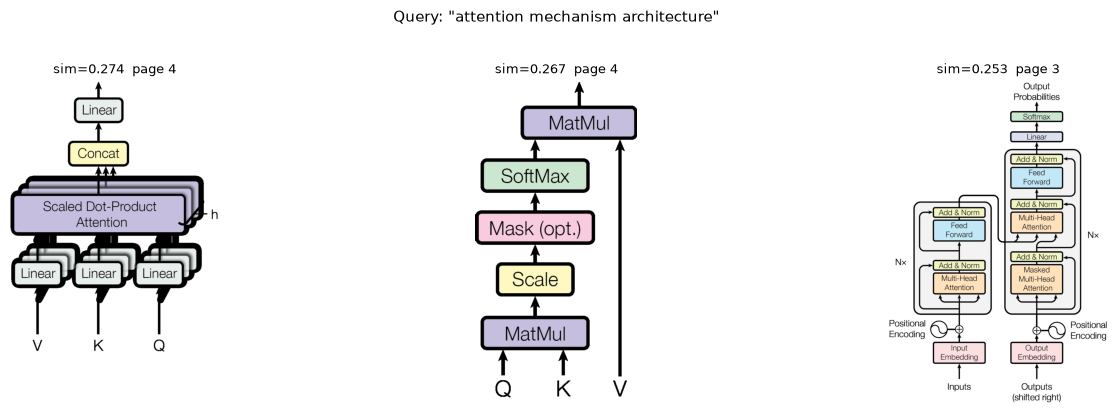

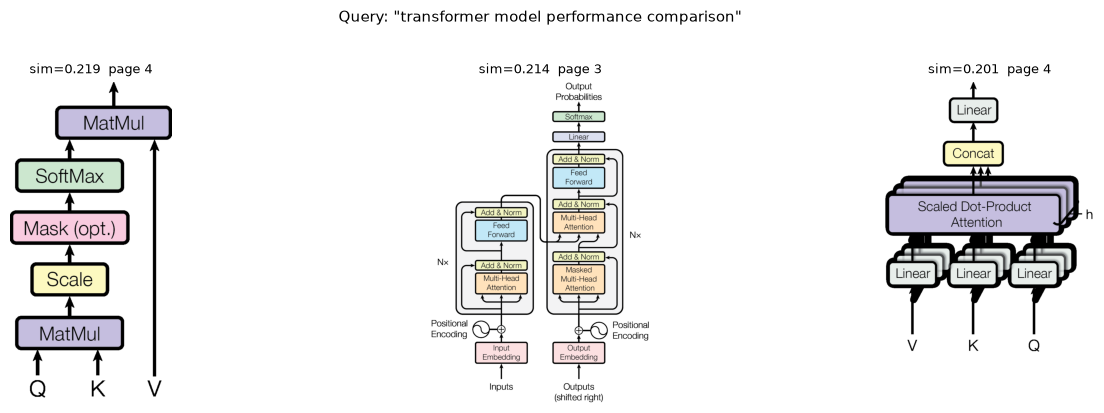

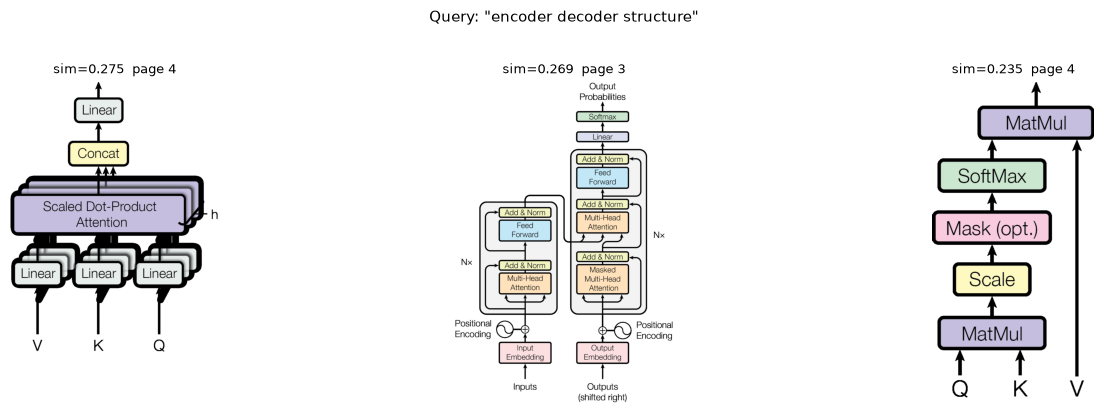

In [5]:
# ## Part 4: Display Retrieved Images
#
# For each query, show the top retrieved images so you can visually
# verify the retrieval quality.

for q in TEXT_QUERIES:
    hits = text_to_image_query(q, top_k=3)
    n = len(hits)
    if n == 0:
        continue

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, h in zip(axes, hits):
        img_path = h["metadata"].get("path", "")
        if img_path and Path(img_path).exists():
            img = Image.open(img_path)
            ax.imshow(img)
        sim = 1 - h["distance"]
        ax.set_title(f"sim={sim:.3f}  page {h['metadata']['page']}", fontsize=9)
        ax.axis("off")

    fig.suptitle(f"Query: \"{q}\"", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

In [6]:
# ## Part 5: Image-to-Text Retrieval
#
# Given an image, find the most relevant text chunks. This is useful
# when you have a figure and want to understand its context in the
# document.

def image_to_text_query(img_path: str, top_k: int = 3) -> list[dict]:
    """Search the text collection with an image query."""
    img = Image.open(img_path).convert("RGB")
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        qvec = model.encode_image(img_tensor)
        qvec = qvec / qvec.norm(dim=-1, keepdim=True)

    results = text_col.query(
        query_embeddings=qvec.numpy().tolist(),
        n_results=top_k,
    )
    hits = []
    for i in range(len(results["ids"][0])):
        hits.append({
            "id": results["ids"][0][i],
            "document": results["documents"][0][i],
            "distance": results["distances"][0][i],
            "metadata": results["metadatas"][0][i],
        })
    return hits

# Use the first available extracted image.
EXTRACT_DIR = DATA / "multimodal_images"
sample_imgs = sorted(EXTRACT_DIR.glob("page*_img*.*")) if EXTRACT_DIR.exists() else []

if sample_imgs:
    query_img = str(sample_imgs[0])
    print(f"Image query: {Path(query_img).name}")
    hits = image_to_text_query(query_img, top_k=3)
    print("-" * 60)
    for rank, h in enumerate(hits, 1):
        sim = 1 - h["distance"]
        print(f"  #{rank} sim={sim:.4f}  page {h['metadata']['page']}")
        print(f"      {h['document'][:150]}...")
        print()
else:
    print("[SKIP] No extracted images found. Run notebook 02 first.")

Image query: page3_img1.png
------------------------------------------------------------
  #1 sim=0.3136  page 3
      Figure 1: The Transformer - model architecture.
The Transformer follows this overall architecture using stacked self-attention and point-wise, fully
c...

  #2 sim=0.3016  page 5
      output values. These are concatenated and once again projected, resulting in the final values, as
depicted in Figure 2.
Multi-head attention allows th...

  #3 sim=0.2621  page 4
      Scaled Dot-Product Attention
Multi-Head Attention
Figure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several
atte...



In [7]:
# ## Part 6: Bidirectional Retrieval -- Search Both Directions
#
# A powerful pattern: for a given text query, retrieve both relevant
# text chunks AND relevant images, then combine them.

def bidirectional_query(query: str, text_k: int = 3, img_k: int = 3) -> dict:
    """Search both text and image collections with a text query."""
    tokens = tokenizer([query]).to(device)
    with torch.no_grad():
        qvec = model.encode_text(tokens)
        qvec = qvec / qvec.norm(dim=-1, keepdim=True)

    qvec_np = qvec.numpy().tolist()

    # Search text collection.
    text_results = text_col.query(query_embeddings=qvec_np, n_results=text_k)
    text_hits = []
    for i in range(len(text_results["ids"][0])):
        text_hits.append({
            "type": "text",
            "id": text_results["ids"][0][i],
            "document": text_results["documents"][0][i],
            "distance": text_results["distances"][0][i],
            "metadata": text_results["metadatas"][0][i],
        })

    # Search image collection.
    img_hits = []
    if img_col.count() > 0:
        img_results = img_col.query(query_embeddings=qvec_np, n_results=min(img_k, img_col.count()))
        for i in range(len(img_results["ids"][0])):
            img_hits.append({
                "type": "image",
                "id": img_results["ids"][0][i],
                "document": img_results["documents"][0][i],
                "distance": img_results["distances"][0][i],
                "metadata": img_results["metadatas"][0][i],
            })

    # Combine and sort by distance (lower is better in ChromaDB).
    all_hits = text_hits + img_hits
    all_hits.sort(key=lambda x: x["distance"])

    return {"text_hits": text_hits, "img_hits": img_hits, "combined": all_hits}

# Demo: bidirectional query.
bq = "self-attention and multi-head attention"
result = bidirectional_query(bq)

print(f"Bidirectional query: \"{bq}\"")
print("=" * 60)
print(f"\nText results ({len(result['text_hits'])}):")
for rank, h in enumerate(result["text_hits"], 1):
    sim = 1 - h["distance"]
    print(f"  #{rank} sim={sim:.4f}  page {h['metadata']['page']}")
    print(f"      {h['document'][:120]}...")

print(f"\nImage results ({len(result['img_hits'])}):")
for rank, h in enumerate(result["img_hits"], 1):
    sim = 1 - h["distance"]
    print(f"  #{rank} sim={sim:.4f}  page {h['metadata']['page']}  {h['document']}")

Bidirectional query: "self-attention and multi-head attention"

Text results (3):
  #1 sim=0.6627  page 4
      Scaled Dot-Product Attention
Multi-Head Attention
Figure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Atte...
  #2 sim=0.6436  page 5
      output values. These are concatenated and once again projected, resulting in the final values, as
depicted in Figure 2.
...
  #3 sim=0.5852  page 2
      1
Introduction
Recurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks
in particu...

Image results (3):
  #1 sim=0.2800  page 4  page4_img2.png
  #2 sim=0.2385  page 3  page3_img1.png
  #3 sim=0.2295  page 4  page4_img1.png


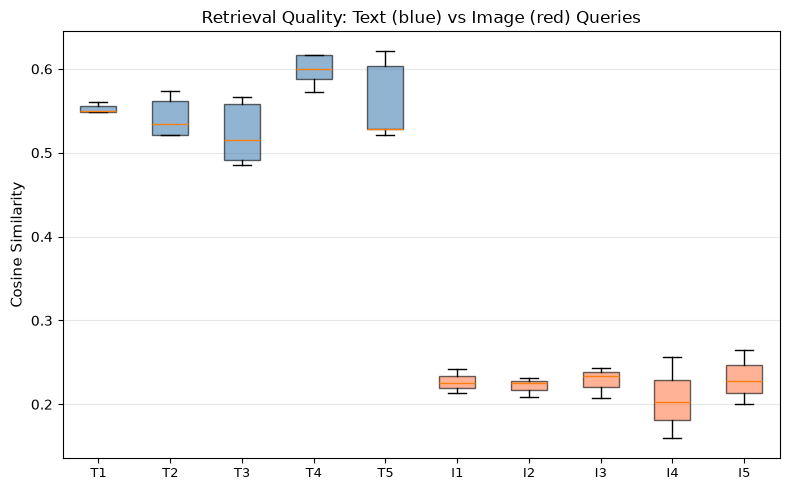

In [8]:
# ## Part 7: Retrieval Quality Analysis
#
# Let us visualize how similarity scores distribute across text and
# image results for a set of queries.

ANALYSIS_QUERIES = [
    "attention mechanism",
    "transformer architecture",
    "encoder decoder",
    "self-attention",
    "multi-head attention",
]

text_sims = []
img_sims = []

for q in ANALYSIS_QUERIES:
    tokens = tokenizer([q]).to(device)
    with torch.no_grad():
        qvec = model.encode_text(tokens)
        qvec = qvec / qvec.norm(dim=-1, keepdim=True)
    qvec_np = qvec.numpy().tolist()

    t_res = text_col.query(query_embeddings=qvec_np, n_results=5)
    text_sims.append([1 - d for d in t_res["distances"][0]])

    if img_col.count() > 0:
        i_res = img_col.query(query_embeddings=qvec_np, n_results=min(5, img_col.count()))
        img_sims.append([1 - d for d in i_res["distances"][0]])

# Box plot comparing text vs image similarity distributions.
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [s for s in text_sims] + [s for s in img_sims]
labels = [f"T{i+1}" for i in range(len(text_sims))] + \
         [f"I{i+1}" for i in range(len(img_sims))]
positions = list(range(1, len(data_to_plot) + 1))

bp = ax.boxplot(data_to_plot, positions=positions, tick_labels=labels, patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor("steelblue" if i < len(text_sims) else "coral")
    patch.set_alpha(0.6)

ax.set_ylabel("Cosine Similarity", fontsize=11)
ax.set_title("Retrieval Quality: Text (blue) vs Image (red) Queries", fontsize=12)
ax.set_xticklabels(labels, fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

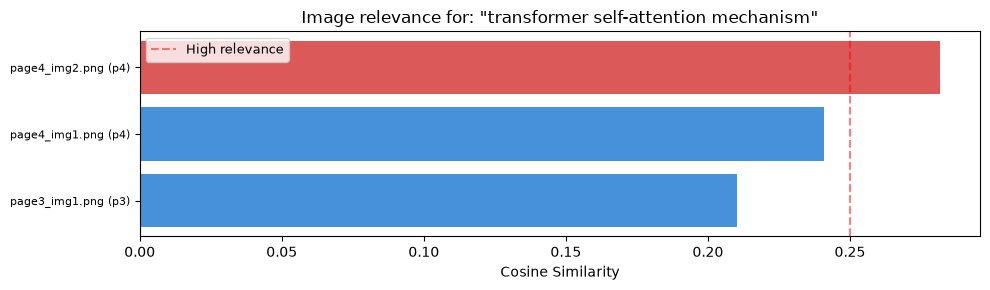

In [9]:
# ## Part 8: Cross-Modal Similarity Visualization
#
# Show the full text-to-image similarity matrix for a few queries
# and all retrieved images.

demo_query = "transformer self-attention mechanism"
tokens = tokenizer([demo_query]).to(device)
with torch.no_grad():
    qvec = model.encode_text(tokens)
    qvec = qvec / qvec.norm(dim=-1, keepdim=True)

if img_col.count() > 0:
    all_img = img_col.get(include=["embeddings", "documents", "metadatas"])
    img_embs = torch.tensor(all_img["embeddings"], dtype=torch.float32)
    img_names = all_img["documents"]
    img_pages = [m["page"] for m in all_img["metadatas"]]

    sims = (qvec.cpu() @ img_embs.T).numpy().flatten()
    ranked = sorted(zip(img_names, img_pages, sims), key=lambda x: -x[2])

    fig, ax = plt.subplots(figsize=(10, max(3, len(ranked) * 0.5)))
    y_pos = range(len(ranked))
    scores = [s for _, _, s in ranked]
    labels = [f"{n} (p{p})" for n, p, _ in ranked]
    colors = ["#d32f2f" if s > 0.25 else "#1976d2" if s > 0.2 else "#9e9e9e" for s in scores]

    ax.barh(y_pos, scores, color=colors, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Cosine Similarity")
    ax.set_title(f"Image relevance for: \"{demo_query}\"")
    ax.invert_yaxis()
    ax.axvline(x=0.25, color="red", linestyle="--", alpha=0.5, label="High relevance")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("[SKIP] No images in collection for visualization.")

In [10]:
# ## Summary
#
# 1. Text-to-image retrieval: text queries search the image collection via CLIP.
# 2. Image-to-text retrieval: image queries search the text collection via CLIP.
# 3. Bidirectional retrieval: combine text and image results in one ranking.
# 4. Similarity scores indicate cross-modal relevance strength.
# 5. ChromaDB handles the vector search; CLIP provides the shared space.
#
# Next: notebook 04 assembles a full multi-modal RAG pipeline.

print("\n[COMPLETE] Module 21 Notebook 3: Cross-Modal Retrieval")
print(f"  - Text collection: {text_col.count()} chunks")
print(f"  - Image collection: {img_col.count()} images")
print("  - Text-to-image retrieval: working")
print("  - Image-to-text retrieval: working")
print("  - Bidirectional retrieval: working")


[COMPLETE] Module 21 Notebook 3: Cross-Modal Retrieval
  - Text collection: 15 chunks
  - Image collection: 3 images
  - Text-to-image retrieval: working
  - Image-to-text retrieval: working
  - Bidirectional retrieval: working
